In [ ]:
# ==============================
# 1. IMPORT LIBRARY
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files

In [ ]:
# ==============================
# 2. UPLOAD DATASET
# ==============================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# rapikan nama kolom
df.columns = df.columns.str.strip().str.lower()

df.head()

Saving StudentsPerformance.csv to StudentsPerformance.csv


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# ==============================
# 3. CEK KOLOM
# ==============================

print(df.columns.tolist())
print(df.shape)

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
(1000, 8)


In [ ]:
# ==============================
# 4. DATA SELECTION AMAN
# ==============================

df.columns = df.columns.str.strip().str.lower()

print("Kolom dataset:")
print(df.columns.tolist())

math_col = [c for c in df.columns if 'math' in c][0]
reading_col = [c for c in df.columns if 'reading' in c][0]
writing_col = [c for c in df.columns if 'writing' in c][0]

data = df[[math_col, reading_col, writing_col]].copy()

print("Ukuran data awal:", data.shape)
data.head()

Kolom dataset:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
Ukuran data awal: (1000, 3)


,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [ ]:
# ==============================
# 5. DATA PREPROCESSING AMAN
# ==============================

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Missing value:")
print(data.isnull().sum())

# jangan langsung drop semua kalau ternyata kosong
data = data.dropna()

print("Ukuran data setelah cleaning:", data.shape)

data.head()

Missing value:
math score       0
reading score    0
writing score    0
dtype: int64
Ukuran data setelah cleaning: (1000, 3)


,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [ ]:
# ==============================
# 6. DATA TRANSFORMATION
# ==============================

from sklearn.preprocessing import StandardScaler

if data.shape[0] == 0:
    print("DATA KOSONG. Cek file yang diupload, pastikan file CSV StudentsPerformance.csv, bukan file .ipynb.")
else:
    df = df.loc[data.index].copy()

    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    print("Data berhasil distandarisasi.")
    print(data_scaled[:5])

Data berhasil distandarisasi.
[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


In [ ]:
# ==============================
# 7. K-MEANS CLUSTERING
# ==============================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(data_scaled)

df[[math_col, reading_col, writing_col, 'cluster']].head()

,math score,reading score,writing score,cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2


In [ ]:
# ==============================
# 8. INTERPRETASI CLUSTER
# ==============================

cluster_mean = df.groupby('cluster')[[math_col, reading_col, writing_col]].mean()

cluster_mean

,math score,reading score,writing score
cluster,,,
0,65.338600,68.458239,67.821670
1,48.096386,50.670683,48.485944
2,81.714286,85.146104,84.207792


In [ ]:
# ==============================
# 9. LABEL KATEGORI NUMERASI
# ==============================

urutan_cluster = cluster_mean[math_col].sort_values().index

mapping = {
    urutan_cluster[0]: 'Rendah',
    urutan_cluster[1]: 'Sedang',
    urutan_cluster[2]: 'Tinggi'
}

df['kategori_numerasi'] = df['cluster'].map(mapping)

df[[math_col, reading_col, writing_col, 'cluster', 'kategori_numerasi']].head()

,math score,reading score,writing score,cluster,kategori_numerasi
0,72,72,74,0,Sedang
1,69,90,88,2,Tinggi
2,90,95,93,2,Tinggi
3,47,57,44,1,Rendah
4,76,78,75,2,Tinggi


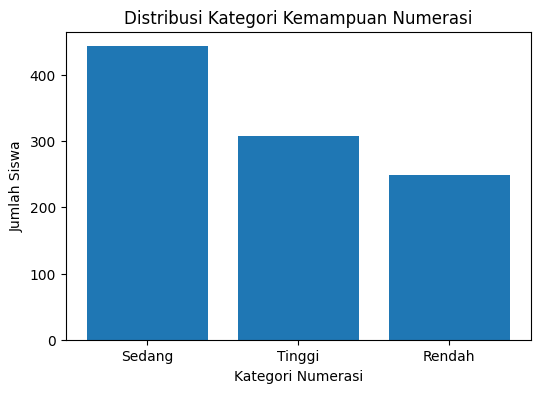

In [ ]:
# ==============================
# 10. VISUALISASI KATEGORI
# ==============================

kategori_counts = df['kategori_numerasi'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(kategori_counts.index, kategori_counts.values)
plt.xlabel("Kategori Numerasi")
plt.ylabel("Jumlah Siswa")
plt.title("Distribusi Kategori Kemampuan Numerasi")
plt.show()

In [ ]:
# ==============================
# 11. RANDOM FOREST
# ==============================

X = df[[math_col, reading_col, writing_col]]
y = df['kategori_numerasi']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [ ]:
# ==============================
# 12. EVALUASI RANDOM FOREST
# ==============================

akurasi = accuracy_score(y_test, y_pred)

print("Akurasi Random Forest:", akurasi)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Random Forest: 0.97

Classification Report:
              precision    recall  f1-score   support

      Rendah       0.98      0.95      0.96        57
      Sedang       0.96      0.96      0.96        83
      Tinggi       0.97      1.00      0.98        60

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



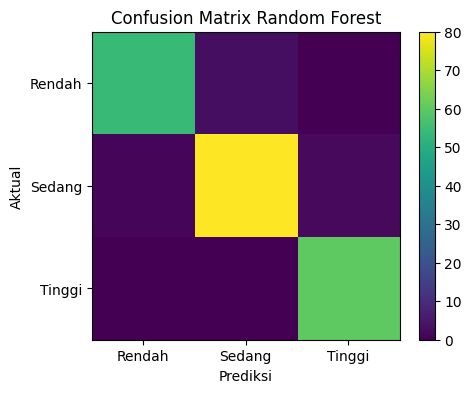

In [ ]:
# ==============================
# 13. CONFUSION MATRIX
# ==============================

labels = ['Rendah', 'Sedang', 'Tinggi']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.xticks([0,1,2], labels)
plt.yticks([0,1,2], labels)
plt.colorbar()
plt.show()

In [ ]:
# ==============================
# 14. PREDIKSI SEMUA DATA
# ==============================

df['prediksi_random_forest'] = rf.predict(X)

df[[math_col, reading_col, writing_col,
    'kategori_numerasi', 'prediksi_random_forest']].head()

,math score,reading score,writing score,kategori_numerasi,prediksi_random_forest
0,72,72,74,Sedang,Sedang
1,69,90,88,Tinggi,Tinggi
2,90,95,93,Tinggi,Tinggi
3,47,57,44,Rendah,Rendah
4,76,78,75,Tinggi,Tinggi


In [ ]:
# ==============================
# 15. REKOMENDASI PEMBELAJARAN
# ==============================

def rekomendasi(kategori):
    if kategori == 'Rendah':
        return 'Remedial'
    elif kategori == 'Sedang':
        return 'Penguatan Materi'
    else:
        return 'Pengayaan'

df['rekomendasi'] = df['prediksi_random_forest'].apply(rekomendasi)

df[[math_col, 'kategori_numerasi',
    'prediksi_random_forest', 'rekomendasi']].head()

,math score,kategori_numerasi,prediksi_random_forest,rekomendasi
0,72,Sedang,Sedang,Penguatan Materi
1,69,Tinggi,Tinggi,Pengayaan
2,90,Tinggi,Tinggi,Pengayaan
3,47,Rendah,Rendah,Remedial
4,76,Tinggi,Tinggi,Pengayaan


In [ ]:
# ==============================
# 16. SIMPAN DATA UNTUK DASHBOARD
# ==============================

df.to_csv("numeraboard_data.csv", index=False)

files.download("numeraboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>